# Stage 1 — Earth Source Data QA

| Field | Value |
|---|---|
| **Pipeline stage** | Stage 1 — Earth source-data exploration |
| **Previous stage** | Stage 0 — Project setup (`channel_heads/io/paths.py`, `channel_heads/regimes.py`) |
| **Next stage** | Stage 2 — Earth interactive network exploration (`06_earth_network_explorer.ipynb`) |
| **Purpose** | Verify that all 17 Earth basin DEMs exist on disk, load correctly, have a valid CRS, and have sensible elevation ranges. |
| **Inputs** | `data/cropped_DEMs/*.tif` (RAW_KEEP) |
| **Outputs** | Console QA table; no files written. |
| **Decision gate** | All 17 DEMs must load. Any basin with a missing or corrupt DEM must be investigated before proceeding to Stage 5 feature generation. |

## 0. Configuration

In [9]:
# Set to True to show a DEM thumbnail for every basin.
SHOW_THUMBNAILS = True

## 1. Imports and paths

In [10]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from channel_heads.io.paths import EXAMPLE_DEMS, CROPPED_DEMS_DIR
from channel_heads.basin_config import LOCAL_TO_PAPER_BASIN

print(f"DEM directory : {CROPPED_DEMS_DIR}")
print(f"Known basins  : {len(EXAMPLE_DEMS)}")

DEM directory : /Users/guypi/Projects/channel-heads/data/cropped_DEMs
Known basins  : 17


## 2. Per-basin file existence check

In [11]:
rows = []
for basin, path in sorted(EXAMPLE_DEMS.items()):
    rows.append({
        "basin": basin,
        "paper_name": LOCAL_TO_PAPER_BASIN.get(basin, basin),
        "filename": path.name,
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / 1e6, 1) if path.exists() else None,
    })

exist_df = pd.DataFrame(rows)
missing = exist_df[~exist_df["exists"]]

print(f"Present : {exist_df['exists'].sum()}/{len(exist_df)}")
if not missing.empty:
    print(f"MISSING : {missing['basin'].tolist()}")

display(exist_df)

Present : 17/17


,basin,paper_name,filename,exists,size_mb
0,calnalpine,clanalpine,CalnAlpine_strm_crop.tif,True,0.2
1,daqing,daqing,Daqing_strm_crop.tif,True,0.1
2,finisterre,finisterre,Finisterre_strm_crop.tif,True,3.2
3,humboldt,humboldt,Humboldt_strm_crop.tif,True,0.1
4,inyo,inyo,Inyo_strm_crop.tif,True,0.2
5,kammanasie,kammanassie,Kammanasie_strm_crop.tif,True,0.2
6,luliang,luliang,Luliang_strm_crop.tif,True,0.5
7,panamint,panamint,Panamint_strm_crop.tif,True,0.3
8,sakhalin,sakhalin,Sakhalin_strm_crop.tif,True,0.3
9,sierramadre,sierramadre,SierraMadre_strm_crop.tif,True,4.9


## 3. Load each DEM — check CRS, resolution, z-range

In [12]:
try:
    import rasterio
    from rasterio.enums import Resampling
    HAS_RASTERIO = True
except ImportError:
    HAS_RASTERIO = False
    print("rasterio not available — install with: pip install rasterio")

qa_rows = []

if HAS_RASTERIO:
    for basin, path in sorted(EXAMPLE_DEMS.items()):
        row: dict = {"basin": basin, "ok": False, "error": None}
        if not path.exists():
            row["error"] = "FILE_MISSING"
            qa_rows.append(row)
            continue
        try:
            with rasterio.open(path) as src:
                crs = src.crs
                res_x, res_y = src.res
                w, h = src.width, src.height
                nodata = src.nodata
                data = src.read(1).astype(float)

            valid = data if nodata is None else data[data != nodata]
            row.update({
                "ok": True,
                "crs": str(crs),
                "is_projected": crs.is_projected if crs else None,
                "res_x_m": round(res_x, 1),
                "res_y_m": round(res_y, 1),
                "width_px": w,
                "height_px": h,
                "nodata": nodata,
                "z_min": round(float(np.nanmin(valid)), 1) if len(valid) else None,
                "z_max": round(float(np.nanmax(valid)), 1) if len(valid) else None,
                "z_range": round(float(np.nanmax(valid) - np.nanmin(valid)), 1) if len(valid) else None,
                "pct_nodata": round(100 * (1 - len(valid) / data.size), 2),
            })
        except Exception as exc:
            row["error"] = str(exc)
        qa_rows.append(row)

    qa_df = pd.DataFrame(qa_rows)

    failed = qa_df[~qa_df["ok"]]
    print(f"Loaded OK : {qa_df['ok'].sum()}/{len(qa_df)}")
    if not failed.empty:
        print(f"FAILED    : {failed[['basin','error']].to_string(index=False)}")

    display(qa_df.drop(columns=["error"], errors="ignore"))

Loaded OK : 17/17


,basin,ok,crs,is_projected,res_x_m,res_y_m,width_px,height_px,nodata,z_min,z_max,z_range,pct_nodata
0,calnalpine,True,EPSG:4326,False,0.0,0.0,360,256,0.0,1020.0,2677.0,1657.0,0.00
1,daqing,True,EPSG:4326,False,0.0,0.0,349,157,0.0,1072.0,2293.0,1221.0,0.00
2,finisterre,True,EPSG:4326,False,0.0,0.0,1674,943,0.0,1.0,4096.0,4095.0,19.02
3,humboldt,True,EPSG:4326,False,0.0,0.0,219,320,0.0,1313.0,2984.0,1671.0,0.00
4,inyo,True,EPSG:4326,False,0.0,0.0,284,289,0.0,329.0,3363.0,3034.0,0.00
5,kammanasie,True,EPSG:4326,False,0.0,0.0,414,212,0.0,475.0,1935.0,1460.0,0.00
6,luliang,True,EPSG:4326,False,0.0,0.0,756,349,0.0,857.0,2397.0,1540.0,0.00
7,panamint,True,EPSG:4326,False,0.0,0.0,393,351,0.0,14.0,3344.0,3330.0,0.00
8,sakhalin,True,EPSG:4326,False,0.0,0.0,354,435,0.0,1.0,1028.0,1027.0,5.91
9,sierramadre,True,EPSG:4326,False,0.0,0.0,1551,1582,0.0,-4.0,3105.0,3109.0,18.10


## 4. CRS consistency check

In [13]:
if HAS_RASTERIO and 'crs' in qa_df.columns:
    crs_counts = qa_df['crs'].value_counts()
    print("CRS distribution:")
    print(crs_counts.to_string())
    print()
    unprojected = qa_df[qa_df['is_projected'] == False]
    if not unprojected.empty:
        print(f"WARNING: {len(unprojected)} basin(s) have geographic (non-projected) CRS:")
        print(unprojected[['basin','crs']].to_string(index=False))
    else:
        print("All basins have projected CRS. ✓")

CRS distribution:
crs
EPSG:4326    17

            basin       crs
       calnalpine EPSG:4326
           daqing EPSG:4326
       finisterre EPSG:4326
         humboldt EPSG:4326
             inyo EPSG:4326
       kammanasie EPSG:4326
          luliang EPSG:4326
         panamint EPSG:4326
         sakhalin EPSG:4326
      sierramadre EPSG:4326
sierranevadaspain EPSG:4326
           taiwan EPSG:4326
            toano EPSG:4326
          troodos EPSG:4326
          tsugaru EPSG:4326
      vallefertil EPSG:4326
             yoro EPSG:4326


## 5. Elevation range summary

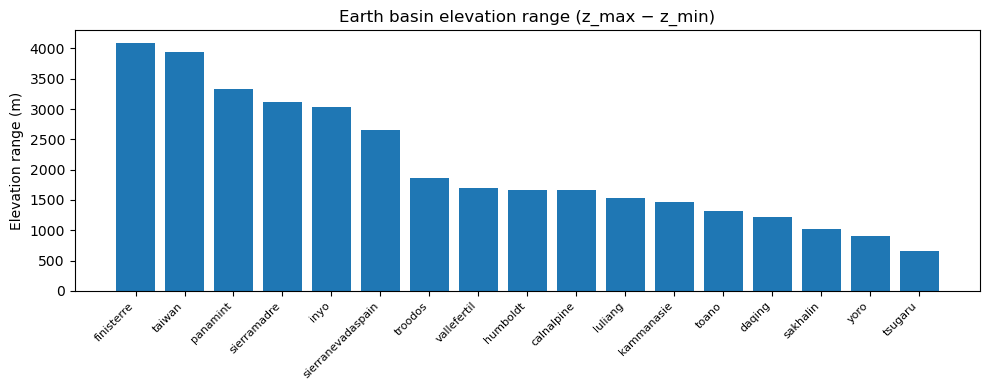


Suspiciously flat basins (z_range < 50 m):
  None.


In [14]:
if HAS_RASTERIO and 'z_range' in qa_df.columns:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 4))
    ok = qa_df[qa_df['ok']].sort_values('z_range', ascending=False)
    x = range(len(ok))
    ax.bar(x, ok['z_range'], label='z_range')
    ax.set_xticks(list(x))
    ax.set_xticklabels(ok['basin'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Elevation range (m)')
    ax.set_title('Earth basin elevation range (z_max − z_min)')
    fig.tight_layout()
    plt.show()

    print("\nSuspiciously flat basins (z_range < 50 m):")
    flat = ok[ok['z_range'] < 50]
    if flat.empty:
        print("  None.")
    else:
        print(flat[['basin','z_range']].to_string(index=False))

## 6. Optional DEM thumbnails

In [ ]:
if HAS_RASTERIO and SHOW_THUMBNAILS:
    import math
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.ticker import FuncFormatter

    # --- helpers applied to every panel ---

    def _deg_lon_fmt(x, pos):
        return f'{abs(x):.2f}°{"E" if x >= 0 else "W"}'

    def _deg_lat_fmt(y, pos):
        return f'{abs(y):.2f}°{"N" if y >= 0 else "S"}'

    def _add_scale_bar(ax, left, right, bottom, top):
        lat_c = (bottom + top) / 2
        km_per_deg_lon = 111.32 * math.cos(math.radians(lat_c))
        panel_km = (right - left) * km_per_deg_lon
        sb_km = next(k for k in [0.5, 1, 2, 5, 10, 20, 50, 100, 200]
                     if k < panel_km * 0.35)
        sb_deg = sb_km / km_per_deg_lon
        sb_x0  = left   + (right - left)   * 0.05
        sb_y0  = bottom + (top   - bottom) * 0.05
        sb_h   = (top - bottom) * 0.018
        ax.add_patch(plt.Rectangle(
            (sb_x0, sb_y0), sb_deg, sb_h,
            facecolor='black', edgecolor='none', zorder=5,
            transform=ax.transData))
        ax.text(sb_x0 + sb_deg / 2, sb_y0 + sb_h * 1.8,
                f'{sb_km:g} km', ha='center', va='bottom',
                fontsize=5, color='black', zorder=6,
                bbox=dict(facecolor='white', alpha=0.7,
                          edgecolor='none', pad=0.5))

    def _add_north_arrow(ax):
        ax.annotate('', xy=(0.94, 0.94), xytext=(0.94, 0.80),
                    xycoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='black',
                                   lw=1.5, mutation_scale=10))
        ax.text(0.94, 0.96, 'N', transform=ax.transAxes,
                ha='center', va='bottom', fontsize=7,
                fontweight='bold', color='black')

    basins_ok = sorted(EXAMPLE_DEMS.keys())
    ncols = 5
    nrows = -(-len(basins_ok) // ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4 * ncols, 3.5 * nrows))
    axes = axes.flatten()

    for i, basin in enumerate(basins_ok):
        ax = axes[i]
        path = EXAMPLE_DEMS[basin]
        if not path.exists():
            ax.set_title(f"{basin}\n(MISSING)", color='red', fontsize=8)
            ax.axis('off')
            continue

        with rasterio.open(path) as src:
            scale = 512 / max(src.width, src.height)
            out_w = max(1, int(src.width  * scale))
            out_h = max(1, int(src.height * scale))
            data  = src.read(
                1, out_shape=(out_h, out_w),
                resampling=Resampling.bilinear
            ).astype(float)
            nd = src.nodata
            left, right, bottom, top = (src.bounds.left, src.bounds.right,
                                         src.bounds.bottom, src.bounds.top)

        if nd is not None:
            data[data == nd] = np.nan

        lo, hi = np.nanpercentile(data, [2, 98])
        ax.imshow(data, cmap='terrain', vmin=lo, vmax=hi,
                  extent=[left, right, bottom, top],
                  aspect='auto', origin='upper')

        # lat/lon axis labels
        ax.xaxis.set_major_formatter(FuncFormatter(_deg_lon_fmt))
        ax.yaxis.set_major_formatter(FuncFormatter(_deg_lat_fmt))
        ax.xaxis.set_major_locator(plt.MaxNLocator(3, prune='both'))
        ax.yaxis.set_major_locator(plt.MaxNLocator(3, prune='both'))
        ax.tick_params(labelsize=5, pad=1)
        ax.set_xlim(left, right)
        ax.set_ylim(bottom, top)

        _add_scale_bar(ax, left, right, bottom, top)
        _add_north_arrow(ax)

        paper = LOCAL_TO_PAPER_BASIN.get(basin, basin)
        ax.set_title(f'{basin}' + (f'\n({paper})' if paper != basin else ''),
                     fontsize=7)

    for j in range(len(basins_ok), len(axes)):
        axes[j].axis('off')

    fig.suptitle('Earth DEM thumbnails (2–98th pct stretch)', y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("Set SHOW_THUMBNAILS = True to render DEM thumbnails.")


## 7. Gate summary

In [8]:
if HAS_RASTERIO:
    n_ok = int(qa_df['ok'].sum())
    n_total = len(qa_df)
    if n_ok == n_total:
        print(f"Stage 1 QA PASSED — all {n_total} DEMs present, load, and have valid metadata.")
    else:
        failed_list = qa_df[~qa_df['ok']]['basin'].tolist()
        raise AssertionError(
            f"Stage 1 QA FAILED — {n_total - n_ok} DEM(s) did not load: {failed_list}\n"
            "Resolve missing or corrupt DEMs before proceeding to Stage 5."
        )
else:
    print("rasterio not available — install it to run the full QA gate.")

Stage 1 QA PASSED — all 17 DEMs present, load, and have valid metadata.
